## Neural Networks Warmup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.inspection import PartialDependenceDisplay

For the first part of this warmup, you'll be working with the penguins data. For simplicity, we'll drop any rows with missing values.

In [2]:
penguins = pd.read_csv('../data/penguins.csv').dropna().reset_index(drop = True)

penguins.sample(5)[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']].head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
17,35.9,19.2,189.0,3800.0,Adelie
155,46.8,15.4,215.0,5150.0,Gentoo
102,38.1,17.0,181.0,3175.0,Adelie
250,53.4,15.8,219.0,5500.0,Gentoo
72,36.2,16.1,187.0,3550.0,Adelie


We'll be predicting the species based on the numeric features.

In [3]:
variables = ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']

X = penguins[variables]
y = penguins['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 321, stratify = y)

## Part 1: Create a Pipeline object named `nn_pipe` with two steps.
Step one should be a StandardScaler and step two should be an [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html). The MLPClassifier whould have a single hidden layer with 2 neurons and use a hyperbolic tangent activation.

Note: you may need to increase the max_iter in order for this to converge.

In [4]:
nn_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('nn', MLPClassifier(hidden_layer_sizes=(2,), max_iter=10000))
    ]
).fit(X_train, y_train)

## Part 2: How well did your model do on the test set?
Look at a confusion matrix and classification report.

## ANSWER: PERFECT

In [5]:
confusion_matrix(
    y_true=y_test,
    y_pred=nn_pipe.predict(X_test)
)

array([[37,  0,  0],
       [ 0, 17,  0],
       [ 0,  0, 30]])

In [6]:
print(
    classification_report(
        y_true=y_test,
        y_pred=nn_pipe.predict(X_test)
    )
)

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        37
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        30

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



For fun, if we want to extract out the new features that were created by the model, we can do so by extracting out the fit attributes and creating an MLPRegressor object with those attributes.

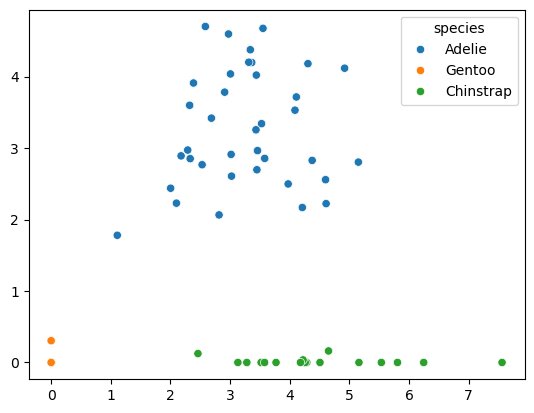

In [7]:
encoder = MLPRegressor()

encoder.coefs_ = nn_pipe['nn'].coefs_[:-1]
encoder.intercepts_ = nn_pipe['nn'].intercepts_[:-1]
encoder.n_layers_ = nn_pipe['nn'].n_layers_ - 1
encoder.out_activation_ = nn_pipe['nn'].activation

penguins_encoded = encoder.predict(nn_pipe[0].transform(X_test))

sns.scatterplot(x = penguins_encoded[:,0], y = penguins_encoded[:,1], hue = y_test, legend = True);

Now, let's see how well a neural network does at predicting home prices.

In [8]:
kc_sales = pd.read_csv("../data/kc_house_data.csv")

X = kc_sales.drop(columns = ['id', 'date', 'price'])
y = kc_sales['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 321)

## Part 3: Create a pipeline object to fit an [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html). 
Make sure that you one-hot encode the zipcode column and apply a StandardScaler to all other features. Use the default hiden_layer_size of 100.

**Note:** you may need to increase the max iterations, but don't increase it to more than 1000.

In [9]:
features = [x for x in X.columns if x != 'zipcode']

In [10]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode']),
        ('scaler', StandardScaler(), features)
    ],
    remainder='passthrough'
)

nn_pipe = Pipeline(
    steps=[
        ('transformer', ct),
        ('nn', MLPRegressor(max_iter=200))
    ]
).fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
y_pred = nn_pipe.predict(X_test)

In [12]:
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 292814550994.9538
RMSE: 541123.4156779337
MAE: 447345.79348168353
MAPE: 0.8461040532596652
R2: -1.212846530230522


## Part 4: Now try using 2 hidden layers, each with hidden layer size of 25.
How does this change the performance of your model?

In [13]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode']),
        ('scaler', StandardScaler(), features)
    ],
    remainder='passthrough'
)

nn_pipe = Pipeline(
    steps=[
        ('transformer', ct),
        ('nn', MLPRegressor(max_iter=200, hidden_layer_sizes=(25, 25)))
    ]
).fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
y_pred = nn_pipe.predict(X_test)

In [15]:
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 29571246914.763527
RMSE: 171962.9230815862
MAE: 99984.2737922037
MAPE: 0.20146602932652927
R2: 0.7765253437454609


## Part 5: Finally, use [PartialDependenceDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html) to plot how the model uses the sqft_living and long to make predictions.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


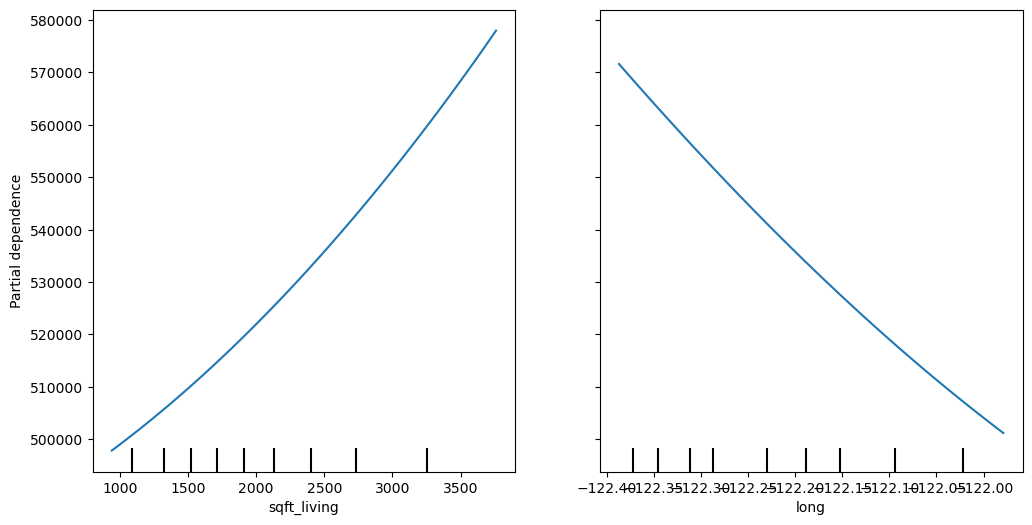

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    estimator=nn_pipe,
    X=X,
    features=['sqft_living', 'long'],
    ax=ax
);